![header](../figures/logos_partenaires._cmems_se.jpg)

# Benchmark DUACS sea surface height maps

<div style="text-align: right"><i> 2023-04-27 DUACS_SSH_BENCHMARK_DEMO </i></div>

***
**Authors:**  CLS & Datlas <br>
**Copyright:** 2023 CLS & Datlas <br>
**License:** MIT

<div class="alert alert-block alert-success">
<h1><center>Benchmark of DUACS sea surface height maps</center></h1>
<h5> The notebook aims to evaluate the sea surface height maps produced by the DUACS system. </h5>
    <h5> These maps are equivalent to the SEALEVEL_GLO_PHY_L4_MY_008_047 product distributed by the Copernicus Marine Service, except that a nadir altimeter (SARAL/Altika, SEALEVEL_GLO_PHY_L3_MY_008_062 product) has been excluded from the mapping. </h5>
        <h5> We provide below a demonstration of the validation of these maps against the independent SSH data from the Saral/AltiKa altimeter distributed by CMEMS </h5>
</div>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Cell" and select "Run All Above Selected Cell".<br>
***


<div class="alert alert-danger" role="alert">

<h3>Learning outcomes</h3>

At the end of this notebook you will know:
<ul>
  <li>How you can evaluated sea surface height maps with independent alongtrack data: statistical and spectral analysis</li>
</ul>
    
</div>

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from glob import glob
import numpy as np
import os

In [34]:
import sys
sys.path.append('..')
from src.mod_plot import *
from src.mod_stat import *
from src.mod_spectral import *
from src.mod_interp import *
from src.mod_filter import *

In [8]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

<div class="alert alert-info" role="alert">

<h2>0. Parameters</h2>

</div>

In [9]:
time_min = '2023-01-01'                                        # time min for analysis
time_max = '2023-12-31'                                        # time max for analysis
output_dir = '../results'                                      # output directory path
os.system(f'mkdir -p {output_dir}')
method_name = '4DVARNET_SSH_not_SLA'
stat_output_filename = f'{output_dir}/stat_ssh.nc'  # output statistical analysis filename
lambda_min = 65.                                               # minimun spatial scale in kilometer to consider on the filtered signal
lambda_max = 500.                                              # maximum spatial scale in kilometer to consider on the filtered signal
psd_output_filename = f'{output_dir}/psd_ssh.nc'    # output spectral analysis filename
segment_lenght = 1000.                                         # spectral parameer: along-track segment lenght in kilometer to consider in the spectral analysis

<div class="alert alert-info" role="alert">

<h2>1. Input files</h2>

</div>

## Sea Surface Height from Saral/AltiKa

In [10]:
import glob

In [11]:
%%time
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-16'

list_of_file = sorted(glob.glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/**/**/*2024*/2023/**/*.nc'))
#sorted(glob('../data/independent_alongtrack/alg/2019/*.nc'))
ds_alg = xr.open_mfdataset(list_of_file)#, combine='nested', concat_dim='time')
ds_alg = ds_alg.rename(longitude="lon", latitude="lat").pipe(\
            lambda d: d.where(\
                (d.time.load() >= pd.to_datetime(time_min))\
                & (d.time <= pd.to_datetime(time_max)),\
                drop=True,\
            )\
        )\
        .assign(ssh=lambda d: d.sla_filtered + d.mdt - d.lwe)\
        .sortby("time")[["ssh", "sla_filtered", "sla_unfiltered", "mdt", "lwe"]]

#ds_alg = xr.open_dataset('/Odyssey/public/altimetry_traces/processed_2023_global_4/concat/concatenated_input.nc')

#ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)
#ds_alg = ds_alg.sortby('time')
ds_alg

CPU times: user 47.4 s, sys: 4.41 s, total: 51.8 s
Wall time: 1min 1s


<xarray.Dataset> Size: 859MB
Dimensions:         (time: 13416630)
Coordinates:
  * time            (time) datetime64[ns] 107MB 2023-01-15T23:47:29.547174912...
    lat             (time) float64 107MB -64.98 -64.92 -64.87 ... -63.32 -66.34
    lon             (time) float64 107MB 110.1 110.1 110.0 ... 254.4 254.2 251.3
Data variables:
    ssh             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_filtered    (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_unfiltered  (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    mdt             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    lwe             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea surface height measured by altimeter...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-3 sea su...
    time_coverage_duration:          P23H11M4.556364S
    time_coverage_end:               2023-01-01T23:27:36Z
    time_coverage_resolution:        P1S
    time_coverage_start:             2023-01-01T00:16:31Z
    title:                           DT Altika Drifting Phase Global Ocean Al...

In [12]:
ds_alg = ds_alg.rename({'lon' : 'longitude'})
ds_alg = ds_alg.rename({'lat' : 'latitude'})

## Sea Surface Height maps to evaluate

In [13]:
%%time
list_of_maps = "/Odyssey/public/glorys/rec/glorys4_global_1patch10y/nrt_2023_global_4/test_data_14.nc"
#sorted(glob('../data/maps/DUACS_global_allsat-alg/*.nc'))
ds_maps = xr.open_mfdataset(list_of_maps, combine='nested', concat_dim='time')
ds_maps = ds_maps.sel(time=slice(time_min, time_max))
ds_maps

CPU times: user 14.7 ms, sys: 12.9 ms, total: 27.6 ms
Wall time: 162 ms


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 336, lat: 680, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-01-15 2023-01-16 ... 2023-12-16
  * lat      (lat) float64 5kB -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    out      (time, lat, lon) float32 1GB dask.array<chunksize=(336, 680, 1440), meta=np.ndarray>

In [14]:
ds_maps = ds_maps.rename({'out': 'sla'})
ds_maps = ds_maps.rename({'lon': 'longitude'})
ds_maps = ds_maps.rename({'lat': 'latitude'})

## Very important manipulation in order to make DC21 notebooks work ! 

In [15]:
ds_maps.coords['longitude'] = (ds_maps.coords['longitude'] + 360) % 360
ds_maps = ds_maps.sortby(['longitude'])
#ds_maps = ds_maps.sortby('time')
ds_maps.latitude.attrs['units'] = 'degrees_north'
ds_maps.longitude.attrs['units'] = 'degrees_east'
#ds_maps = ds_maps.sortby('time')

## SLA becomes SSH in our version of evaluation workflow: add MDT as variable to the ds_maps dataset

In [16]:
mdt_ds = xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc")
mdt_3d = np.repeat(mdt_ds.mdt.values[np.newaxis, :, :], 336, axis=0) # 337 days with 15 days missing in the beginning of the year (confirm Pierre)
ds_maps['mdt'] = (['time', 'latitude', 'longitude'], mdt_3d[:,40:,:]) # 40: only for 4dvarnet

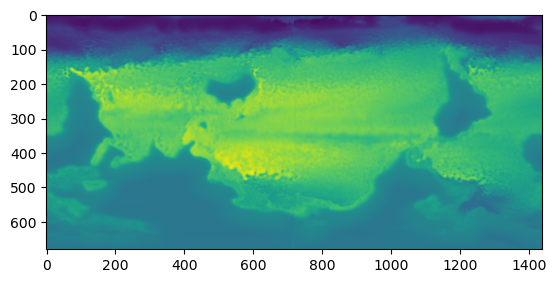

In [17]:
plt.imshow(ds_maps.sla[-1])

<div class="alert alert-info" role="alert">

<h2>2. Statistical & Spectral Analysis </h2>

</div>

## 2.1 Interpolate sea surface height maps onto along-track positions

### 2.1.1 Additionally, interpolate mdt from ds_maps onto along-track positions -> changed /src/mod_interp.py

In [18]:
ds_interp = run_interpolation(ds_maps, ds_alg)
ds_interp = ds_interp.dropna('time')
ds_interp

2025-01-24 14:59:10 INFO     fetch data from 2023-01-15 00:00:00 to 2023-02-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-01-15 23:47:29.547174912  110.138824 -64.983782
2023-01-15 23:47:30.603174912  110.082365 -64.924660
2023-01-15 23:47:31.659174912  110.026133 -64.865520
2023-01-15 23:47:32.715174912  109.970129 -64.806361
2023-01-15 23:47:33.771174656  109.914350 -64.747183
...                                   ...        ...
2023-01-29 15:22:00.193893376  204.468276  57.331215
2023-01-29 15:22:01.249893376  204.432353  57.390977
2023-01-29 15:22:02.305893376  204.396328  57.450730
2023-01-29 15:22:03.361892864  204.360199  57.510475
2023-01-29 15:22:04.417892864  204.323967  57.570211

[593995 rows x 2 columns]


2025-01-24 14:59:13 INFO     fetch data from 2023-01-15 00:00:00 to 2023-02-01 00:00:00
2025-01-24 14:59:13 INFO     fetch data from 2023-01-31 00:00:00 to 2023-03-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-02-08 18:08:07.511931904  179.241529 -18.987470
2023-02-08 18:08:08.567932416  179.226915 -18.925995
2023-02-08 18:08:09.623932416  179.212308 -18.864517
2023-02-08 18:08:10.679932416  179.197709 -18.803039
2023-02-08 18:08:11.735931904  179.183117 -18.741560
...                                   ...        ...
2023-02-28 23:59:28.374580224  244.168367 -70.090690
2023-02-28 23:59:29.430580224  244.083343 -70.147483
2023-02-28 23:59:30.486580224  243.997876 -70.204240
2023-02-28 23:59:31.542580224  243.911963 -70.260959
2023-02-28 23:59:32.598580224  243.825600 -70.317641

[741701 rows x 2 columns]


2025-01-24 14:59:15 INFO     fetch data from 2023-01-31 00:00:00 to 2023-03-01 00:00:00
2025-01-24 14:59:15 INFO     fetch data from 2023-02-28 00:00:00 to 2023-04-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-03-01 00:10:31.972792832  105.367979 -66.076436
2023-03-01 00:10:33.028792832  105.307030 -66.017729
2023-03-01 00:10:34.084792832  105.246340 -65.959001
2023-03-01 00:10:35.140793344  105.185908 -65.900252
2023-03-01 00:10:36.196792832  105.125732 -65.841482
...                                   ...        ...
2023-03-31 23:59:55.118573056  272.919204  28.132815
2023-03-31 23:59:56.174573056  272.903144  28.071802
2023-03-31 23:59:57.230573056  272.887097  28.010788
2023-03-31 23:59:58.286573056  272.871063  27.949772
2023-03-31 23:59:59.342573056  272.855042  27.888754

[1395651 rows x 2 columns]


2025-01-24 14:59:18 INFO     fetch data from 2023-02-28 00:00:00 to 2023-04-01 00:00:00
2025-01-24 14:59:18 INFO     fetch data from 2023-03-31 00:00:00 to 2023-05-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-04-01 00:00:00.398573056  272.839035  27.827735
2023-04-01 00:00:01.454573056  272.823040  27.766714
2023-04-01 00:00:02.510573056  272.807059  27.705692
2023-04-01 00:00:03.566573056  272.791090  27.644668
2023-04-01 00:00:04.622573056  272.775135  27.583643
...                                   ...        ...
2023-04-30 23:59:55.061231616  104.045976 -61.112270
2023-04-30 23:59:56.117231616  104.001674 -61.052229
2023-04-30 23:59:57.173231616  103.957522 -60.992175
2023-04-30 23:59:58.229232128  103.913519 -60.932109
2023-04-30 23:59:59.285232128  103.869665 -60.872031

[1278604 rows x 2 columns]


2025-01-24 14:59:20 INFO     fetch data from 2023-03-31 00:00:00 to 2023-05-01 00:00:00
2025-01-24 14:59:21 INFO     fetch data from 2023-04-30 00:00:00 to 2023-06-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-05-01 00:00:00.341232128  103.825958 -60.811940
2023-05-01 00:00:01.397231616  103.782399 -60.751837
2023-05-01 00:00:02.453231616  103.738985 -60.691722
2023-05-01 00:00:03.509231616  103.695716 -60.631595
2023-05-01 00:00:04.565231616  103.652591 -60.571456
...                                   ...        ...
2023-05-31 23:59:54.754470400  265.578398 -18.192247
2023-05-31 23:59:55.810470400  265.563846 -18.253828
2023-05-31 23:59:56.866470400  265.549287 -18.315407
2023-05-31 23:59:57.922469888  265.534720 -18.376985
2023-05-31 23:59:58.978469888  265.520147 -18.438561

[1353314 rows x 2 columns]


2025-01-24 14:59:23 INFO     fetch data from 2023-04-30 00:00:00 to 2023-06-01 00:00:00
2025-01-24 14:59:24 INFO     fetch data from 2023-05-31 00:00:00 to 2023-07-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-06-01 00:00:00.034469888  265.505566 -18.500137
2023-06-01 00:00:01.090469888  265.490978 -18.561711
2023-06-01 00:00:02.146469888  265.476383 -18.623284
2023-06-01 00:00:03.202470400  265.461780 -18.684856
2023-06-01 00:00:04.258470400  265.447170 -18.746427
...                                   ...        ...
2023-06-30 23:59:55.257963008   89.795972  -9.656118
2023-06-30 23:59:56.313963008   89.782190  -9.594620
2023-06-30 23:59:57.369963008   89.768411  -9.533121
2023-06-30 23:59:58.425963008   89.754635  -9.471621
2023-06-30 23:59:59.481963008   89.740863  -9.410121

[1293200 rows x 2 columns]


2025-01-24 14:59:26 INFO     fetch data from 2023-05-31 00:00:00 to 2023-07-01 00:00:00
2025-01-24 14:59:27 INFO     fetch data from 2023-06-30 00:00:00 to 2023-08-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-07-01 00:00:00.537963008   89.727094  -9.348620
2023-07-01 00:00:01.593963008   89.713328  -9.287119
2023-07-01 00:00:02.649963008   89.699566  -9.225617
2023-07-01 00:00:03.705963008   89.685806  -9.164114
2023-07-01 00:00:04.761963008   89.672050  -9.102611
...                                   ...        ...
2023-07-31 23:57:09.804614144  251.258651 -64.005528
2023-07-31 23:57:10.860614144  251.205603 -64.064867
2023-07-31 23:57:11.916614144  251.152349 -64.124190
2023-07-31 23:57:12.972613632  251.098886 -64.183495
2023-07-31 23:57:14.028613632  251.045213 -64.242783

[1321325 rows x 2 columns]


2025-01-24 14:59:29 INFO     fetch data from 2023-06-30 00:00:00 to 2023-08-01 00:00:00
2025-01-24 14:59:30 INFO     fetch data from 2023-07-31 00:00:00 to 2023-09-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-08-01 00:11:47.570576896  100.347980 -60.006535
2023-08-01 00:11:48.626577408  100.306308 -59.946278
2023-08-01 00:11:49.682577408  100.264769 -59.886010
2023-08-01 00:11:50.738577408  100.223365 -59.825731
2023-08-01 00:11:51.794576896  100.182115 -59.765471
...                                   ...        ...
2023-08-31 23:17:27.960462848   97.260182  11.183561
2023-08-31 23:17:59.640462848   96.843937  13.019752
2023-08-31 23:18:12.312462848   96.676283  13.754096
2023-08-31 23:18:46.104462848   96.225538  15.711918
2023-08-31 23:46:33.373202944  288.601616  62.855598

[1302645 rows x 2 columns]


2025-01-24 14:59:32 INFO     fetch data from 2023-07-31 00:00:00 to 2023-09-01 00:00:00
2025-01-24 14:59:32 INFO     fetch data from 2023-08-31 00:00:00 to 2023-10-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-09-01 00:08:03.805202944  264.306117 -12.948278
2023-09-01 00:08:04.861202944  264.292094 -13.009822
2023-09-01 00:08:05.917202944  264.278065 -13.071365
2023-09-01 00:08:06.973203456  264.264032 -13.132907
2023-09-01 00:08:08.029203456  264.249995 -13.194448
...                                   ...        ...
2023-09-30 22:36:18.086401024  106.332402  18.936976
2023-09-30 22:36:19.142401024  106.317871  18.998105
2023-09-30 22:36:22.310401024  106.274235  19.181486
2023-09-30 22:36:23.366401024  106.259675  19.242612
2023-09-30 22:36:33.926401024  106.113611  19.853965

[1156802 rows x 2 columns]


2025-01-24 14:59:35 INFO     fetch data from 2023-08-31 00:00:00 to 2023-10-01 00:00:00
2025-01-24 14:59:35 INFO     fetch data from 2023-09-30 00:00:00 to 2023-11-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-10-01 00:08:04.966526976   88.051160 -11.715506
2023-10-01 00:08:06.022526976   88.037273 -11.654126
2023-10-01 00:08:07.078526976   88.023391 -11.592745
2023-10-01 00:08:08.134526976   88.009512 -11.531364
2023-10-01 00:08:09.190526976   87.995638 -11.469982
...                                   ...        ...
2023-10-31 23:59:54.925987840  258.918429 -47.862301
2023-10-31 23:59:55.981987840  258.893428 -47.923455
2023-10-31 23:59:57.037987840  258.868378 -47.984605
2023-10-31 23:59:58.093987840  258.843279 -48.045750
2023-10-31 23:59:59.149987840  258.818132 -48.106890

[1287277 rows x 2 columns]


2025-01-24 14:59:37 INFO     fetch data from 2023-09-30 00:00:00 to 2023-11-01 00:00:00
2025-01-24 14:59:38 INFO     fetch data from 2023-10-31 00:00:00 to 2023-12-01 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-11-01 00:00:00.205987840  258.792935 -48.168026
2023-11-01 00:00:01.261987840  258.767689 -48.229157
2023-11-01 00:00:02.317987840  258.742380 -48.290316
2023-11-01 00:00:03.373987840  258.717022 -48.351469
2023-11-01 00:00:04.429987840  258.691614 -48.412616
...                                   ...        ...
2023-11-30 23:18:29.618791936  263.903506 -59.682090
2023-11-30 23:18:32.786791936  263.780076 -59.862691
2023-11-30 23:18:37.010791936  263.613635 -60.103337
2023-11-30 23:18:39.122791936  263.529601 -60.223592
2023-11-30 23:18:40.178791936  263.487377 -60.283703

[1151016 rows x 2 columns]


2025-01-24 14:59:40 INFO     fetch data from 2023-10-31 00:00:00 to 2023-12-01 00:00:00
2025-01-24 14:59:41 INFO     fetch data from 2023-11-30 00:00:00 to 2023-12-16 00:00:00


Interp inside
                                longitude   latitude
time                                                
2023-12-01 00:11:48.308331008   61.251691  69.904063
2023-12-01 00:11:49.364331008   61.169322  69.960160
2023-12-01 00:11:50.420331008   61.086534  70.016223
2023-12-01 00:11:51.476331008   61.003324  70.072251
2023-12-01 00:11:52.532330496   60.919688  70.128243
...                                   ...        ...
2023-12-15 23:47:16.864806400  254.485461 -62.961161
2023-12-15 23:47:17.920805888  254.435834 -63.020802
2023-12-15 23:47:18.976805888  254.386023 -63.080428
2023-12-15 23:47:23.200805888  254.184908 -63.318779
2023-12-15 23:48:17.056805888  251.320796 -66.335434

[541100 rows x 2 columns]


2025-01-24 14:59:43 INFO     fetch data from 2023-11-30 00:00:00 to 2023-12-16 00:00:00


<xarray.Dataset> Size: 1GB
Dimensions:            (time: 13101633)
Coordinates:
  * time               (time) datetime64[ns] 105MB 2023-01-15T23:47:29.547174...
Data variables:
    ssh                (time) float64 105MB -1.295 -1.301 ... -0.768 -0.895
    sla_filtered       (time) float64 105MB 0.034 0.033 0.033 ... 0.009 0.165
    sla_unfiltered     (time) float64 105MB 0.036 0.032 0.04 ... -0.006 0.168
    mdt                (time) float64 105MB -1.313 -1.318 ... -0.756 -1.056
    lwe                (time) float64 105MB 0.016 0.016 0.016 ... 0.021 0.004
    latitude           (time) float64 105MB -64.98 -64.92 ... -63.32 -66.34
    longitude          (time) float64 105MB 110.1 110.1 110.0 ... 254.2 251.3
    msla_interpolated  (time) float64 105MB -1.223 -1.223 ... -0.7446 -0.8857
    mmdt_interpolated  (time) float64 105MB -1.329 -1.33 ... -0.7508 -1.025

### 2.1.2 Now replace SLA from altimeters to SSH: SSH_altimeters = SLA_altimeters + MDT_interpolated

In [19]:
ds_interp['sla_unfiltered_old'] = ds_interp['sla_unfiltered'] # to keep original SLA
ds_interp['sla_filtered_old'] = ds_interp['sla_filtered'] # to keep original SLA
ds_interp['sla_unfiltered'] = ds_interp['sla_unfiltered_old'] + ds_interp['mmdt_interpolated'] # new variable is SSH, but is still called sla ! 
ds_interp['sla_filtered'] = ds_interp['sla_filtered_old'] + ds_interp['mmdt_interpolated'] # new variable is SSH, but is still called sla ! 

In [ ]:
compute_median_dx(ds_interp)

np.float64(6.9877745333057675)

In [ ]:
compute_median_from_multiple_satellites(ds_alg)

np.float64(6.686871279914913)

## 2.2 Compute grid boxes statistics & statistics by regime (coastal, offshore low variability, offshore high variability)

Once the maps have been interpolated to the position of the along-track, it is possible to calculate different statistics on the time series SLA_alongtrack and SLA_maps. 

We propose below the following statistics: error variance maps (static by 1°x1° box), explained variance maps, temporal evolution of global error variance and explained variance. 

These statistics are also applied to the filtered signals focusing on the 65-500km scale range. A bandpass filter is applied before calculating the scores.  

In [ ]:
compute_stat_scores(ds_interp, lambda_min, lambda_max, stat_output_filename,method_name)

2025-01-23 16:35:58 INFO     Compute mapping error all scales


2025-01-23 16:35:58 INFO     Compute mapping error for scales between 65.0 and 500.0 km


Total RMSE= 0.04989820545250539 m
Total RMSE score= 0.9378626546101742 m


2025-01-23 16:36:44 INFO     Compute binning statistics
2025-01-23 16:36:51 INFO     Compute statistics by oceanic regime
2025-01-23 16:37:07 INFO     Stat file saved as: ../results/stat_ssh.nc


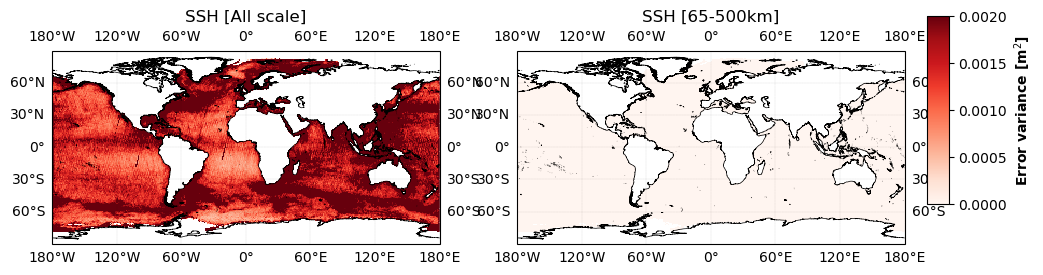

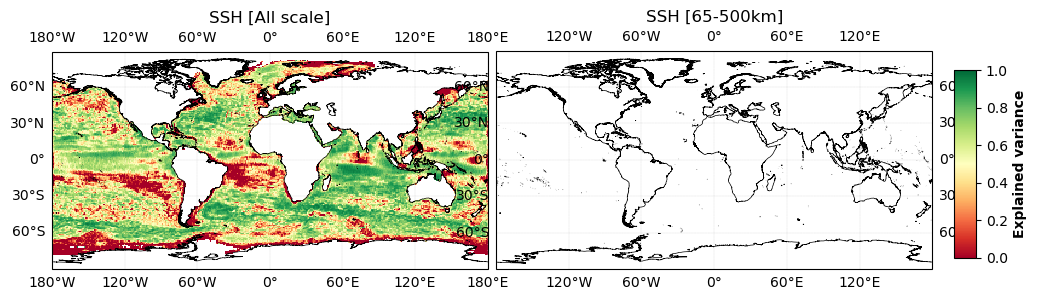

In [ ]:
# Plot gridded stats
# Hvplot
# plot_stat_score_map(stat_output_filename)
# Matplotlib
plot_stat_score_map_png(stat_output_filename)

In [ ]:
plot_stat_score_timeseries(stat_output_filename)

:Layout
   .Overlay.I  :Overlay
      .Curve.All_scale :Curve   [time]   (timeserie_variance_mapping_err)
      .Curve.Filtered  :Curve   [time]   (timeserie_variance_mapping_err)
   .Overlay.II :Overlay
      .Curve.All_scale :Curve   [time]   (explained_variance_score)
      .Curve.Filtered  :Curve   [time]   (explained_variance_score)

### 2.2.1 I modified /src/mod_stat.py in order to add the computation of nRMSE score for mappieng err; I also modified /src/mod_plot.py in order to include RMSE and nRMSE score to the table

In [41]:
from src.mod_plot import plot_stat_by_regimes

In [42]:
plot_stat_by_regimes(stat_output_filename)

,mapping_err_var [m²],mapping_err_rms,mapping_err_nrms_score,sla_unfiltered_var [m²],sla_unfiltered_rms,sla_unfiltered_nrms_score,mapping_err_filtered_var [m²],mapping_err_filtered_rms,mapping_err_filtered_nrms_score,sla_filtered_var [m²],sla_filtered_rms,sla_filtered_nrms_score,var_score_allscale,var_score_filtered
coastal,0.003116,0.055841,0.930462,0.333882,0.825748,0.930462,0.000777,0.027870,0.930462,0.002588,0.050873,0.930462,0.990667,0.699855
offshore_highvar,0.007070,0.084257,0.895076,0.322736,0.782457,0.895076,0.002878,0.053671,0.895076,0.026005,0.162187,0.895076,0.978094,0.889321
offshore_lowvar,0.001889,0.043852,0.945392,0.483569,0.796288,0.945392,0.000449,0.021193,0.945392,0.002345,0.048462,0.945392,0.996095,0.808514
equatorial_band,0.001897,0.043926,0.945299,0.055704,0.882403,0.945299,0.000427,0.020676,0.945299,0.000653,0.025581,0.945299,0.965938,0.344953
arctic,0.002619,0.051393,0.936002,0.014020,0.250924,0.936002,0.000554,0.023538,0.936002,0.000912,0.030214,0.936002,0.813198,0.392730
antarctic,0.006569,0.081061,0.899057,0.004277,1.199008,0.899057,0.000915,0.030255,0.899057,0.000700,0.026469,0.899057,-0.535973,-0.306650


## 2.3 Compute Spectral scores

In [ ]:
compute_psd_scores_v2(ds_interp, psd_output_filename, lenght_scale=segment_lenght,method_name=method_name)

2024-09-11 20:21:28 INFO     Segment computation...
2024-09-11 20:21:40 INFO     Spectral analysis...
2024-09-11 20:36:31 INFO     Saving ouput...
2024-09-11 20:36:40 INFO     PSD file saved as: ../results/psd_sla_duacs_geos.nc


Averaged effective resolution: 276.7763559169713 km


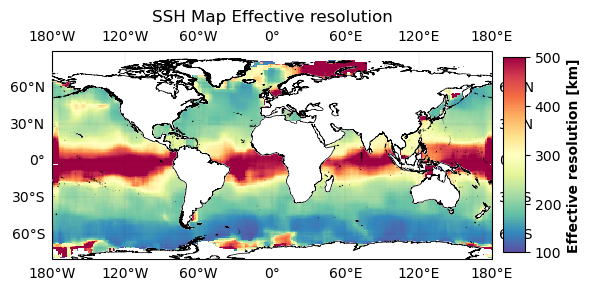

In [20]:
# Plot effective resolution
# Hvplot
# plot_effective_resolution(psd_output_filename)
# Matplotlib
plot_effective_resolution_png(psd_output_filename)

In [ ]:
plot_psd_scores(psd_output_filename)

:Layout
   .DynamicMap.I   :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_alongtrack   :Curve   [wavelenght]   (psd_ref)
         .Curve.NOISE_alongtrack :Curve   [wavelenght]   (noise)
         .Curve.PSD_map          :Curve   [wavelenght]   (psd_study)
         .Curve.PSD_err          :Curve   [wavelenght]   (psd_diff)
   .DynamicMap.II  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_map_over_PSD_ref :Curve   [wavelenght]   (psd_ratio)
         .Curve.I                    :Curve   [wavelenght]   (coherence)
   .DynamicMap.III :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (psd_score)
         .Curve.II :Curve   [wavelenght]   (coherence)
   .DynamicMap.IV  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (coherence)
         .Curve.II :Curve   [wavelenght]   (coherence)

The interactive plot above allows you to explore the spectral metrics by latitude / longitude box